# **Driveline Baseball OpenBiomechanics Pitching Data Exploration**
Data is from of [Driveline Baseball's OpenBiomechanics repository](https://github.com/drivelineresearch/openbiomechanics/tree/main).

## Analysis Rationale & Hypothesis:
**Rationale**: To evaluate the relationship between fastball velocity and standing leg force

**Hypothesis**: The ground reaction force (GRF) acting on the standing leg during a fastball pitch is the engine that drives fastball velocity. There should be a strong, positively-correlated relationship between fastball velocity and standing leg force since a pitcher pushes off the standing leg to throw a pitch.

## Data of Interest:
* Pitcher metadata
* Standing leg force plate
* Joint velocities to examine movement sequencing patterns

In [1]:
import numpy as np
import pandas as pd
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

C:\Users\Marchiano\AppData\Local\Temp\ipykernel_6972\1490163105.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install data-profiling via `pip install data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [2]:
# Import datasets
pitching_data_folder = 'C:\\Users\\Marchiano\\Documents\\Projects\Baseball-Biomechanics\\Pitching_biomechanics_data\\'

pitcher_metadata_df = pd.read_csv(pitching_data_folder + 'metadata.csv', header=0)
force_plate_df = pd.read_csv(pitching_data_folder + 'force_plate.csv', header=0)

## Pitcher Metadata Exploration

In [3]:
# Preview pitcher metadata
pitcher_metadata_df.head()

,user,session,session_pitch,session_mass_kg,session_height_m,age_yrs,playing_level,pitch_speed_mph,filename_new,modelname_new
0,750,1031,1031_2,110.6784,1.9304,21.40,college,90.4,000750_001031_76_244_013_FF_904.c3d,000750_001031_model.c3d
1,750,1031,1031_3,110.6784,1.9304,21.40,college,90.4,000750_001031_76_244_014_FF_904.c3d,000750_001031_model.c3d
2,774,1097,1097_1,101.1528,1.9304,19.41,college,77.6,000774_001097_76_223_001_FF_776.c3d,000774_001097_model.c3d
3,774,1097,1097_2,101.1528,1.9304,19.41,college,77.0,000774_001097_76_223_005_FF_770.c3d,000774_001097_model.c3d
4,774,1097,1097_3,101.1528,1.9304,19.41,college,76.1,000774_001097_76_223_006_FF_761.c3d,000774_001097_model.c3d


In [4]:
pitcher_profile = ProfileReport(pitcher_metadata_df[['session_mass_kg', 'session_height_m', 'age_yrs', 'playing_level', 'pitch_speed_mph']], 
                                title="Pitcher Metadata Profiling Report")
pitcher_profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 55.04it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### Simplified View of Metadata
Output playing level metadata breakdown for convenient view

In [5]:
pitcher_metadata_df['playing_level'].value_counts()

playing_level
college        314
independent     42
high_school     32
milb            23
Name: count, dtype: int64

In [6]:
pitcher_metadata_df.groupby('playing_level')[['session_mass_kg']].describe()

session_mass_kg                                           \
                        count        mean        std      min      25%   
playing_level                                                            
college                 314.0   88.450555   8.509943  69.4008  82.5552   
high_school              32.0   85.957200   9.044156  73.4832  76.2048   
independent              42.0  102.513600   8.540899  88.4520  98.4312   
milb                     23.0   99.101739  10.226249  83.4624  93.8952   

                                             
                    50%       75%       max  
playing_level                                
college         87.5448   93.8952  111.1320  
high_school     85.2768   96.1632   97.5240  
independent    103.4208  105.6888  118.3896  
milb            97.5240  103.8744  113.8536

In [7]:
pitcher_metadata_df.groupby('playing_level')[['session_height_m']].describe()

session_height_m                                              \
                         count      mean       std     min     25%     50%   
playing_level                                                                
college                  314.0  1.841500  0.069010  1.6764  1.8034  1.8542   
high_school               32.0  1.883569  0.042848  1.8288  1.8288  1.9050   
independent               42.0  1.885648  0.082030  1.6764  1.8796  1.8796   
milb                      23.0  1.879600  0.035095  1.8034  1.8542  1.8796   

                                
                   75%     max  
playing_level                   
college        1.87960  2.0320  
high_school    1.93040  1.9304  
independent    1.92405  2.0066  
milb           1.90500  1.9304

In [8]:
pitcher_metadata_df.groupby('playing_level')[['age_yrs']].describe()

age_yrs                                                         
                count       mean       std    min     25%    50%    75%    max
playing_level                                                                 
college         314.0  20.813280  1.502779  18.00  19.610  20.61  21.51  25.07
high_school      32.0  18.422812  0.426956  17.68  18.130  18.62  18.74  18.94
independent      42.0  24.977143  1.433975  22.26  24.055  25.04  25.61  27.59
milb             23.0  25.073478  1.543024  23.13  23.620  25.16  25.35  27.46

In [9]:
pitcher_metadata_df.groupby('playing_level')[['pitch_speed_mph']].describe()

pitch_speed_mph                                            \
                        count       mean       std   min     25%    50%   
playing_level                                                             
college                 314.0  84.733758  4.377185  71.4  81.825  85.10   
high_school              32.0  79.515625  3.848679  73.8  76.250  79.35   
independent              42.0  85.942857  5.429241  69.5  83.550  87.80   
milb                     23.0  89.247826  1.643685  86.3  87.850  89.40   

                            
                 75%   max  
playing_level               
college        87.70  94.4  
high_school    81.60  86.8  
independent    89.45  93.1  
milb           90.70  92.0

## 4-Seam Fastball Velocity (mph) vs. Standing Leg Vertical Force Applied (N)
Fastball velocity and force plate data is found in metadata.csv and force_plate.csv respectively.

**N.B.** 8 pitches in metadata.csv have corresponding biomechanical data (i.e., force plate data); hence the need to use pitch IDs to get correpsponding data from metadata.csv

In [10]:
# Preview force plate data
force_plate_df.head()

,session_pitch,time,rear_force_x,rear_force_y,rear_force_z,lead_force_x,lead_force_y,lead_force_z,pkh_time,fp_10_time,fp_100_time,MER_time,BR_time,MIR_time
0,1031_2,0.0000,82.5463,-5.4519,581.2194,-0.2830,-0.2980,-0.7653,0.625,1.1806,1.1917,1.3056,1.3389,1.3778
1,1031_2,0.0009,82.5354,-5.2039,578.6810,-0.3239,-0.2989,-0.7273,0.625,1.1806,1.1917,1.3056,1.3389,1.3778
2,1031_2,0.0019,82.5264,-4.9488,576.0246,-0.3632,-0.2984,-0.6948,0.625,1.1806,1.1917,1.3056,1.3389,1.3778
3,1031_2,0.0028,82.5200,-4.6900,573.2703,-0.4002,-0.2967,-0.6686,0.625,1.1806,1.1917,1.3056,1.3389,1.3778
4,1031_2,0.0037,82.5173,-4.4309,570.4384,-0.4340,-0.2937,-0.6488,0.625,1.1806,1.1917,1.3056,1.3389,1.3778


In [11]:
# Function to denote where an event (e.g, pitch, swing) begins as indicated by time 0 in data
# ACCEPTS: pandas series with time data
# RETURNS: numpy array with indices from the pandas series denoting when each event begins

def get_event_starts(time_series_column):
    return np.where(time_series_column == 0)[0]

In [12]:
# Function to return an array with event ID and another arrray with the peak outcome measure value of interest for each recorded event (e.g., pitch, swing)
# ACCEPTS: - one dataframe consisting of the event ID column, time, at least 1 outcome measure column
#          - name of outcome measure column of interest as a string
# RETURNS: 2 numpy arrays: event IDs (as strings) and outcome measure values (as floats)
#          Example outputs: [1031_2, 1031_3,...], [1000, 1500,...]

def get_event_value(data_df, outcome_measure):

    # set constants
    event_id_column = data_df.columns[0] # assuming the dataset has the event ID in the first column like it is for driveline openbiomechanics datasets
    
    # crop events in dataframe
    event_starts_array = get_event_starts(data_df['time'])

    last_event_index = event_starts_array[-1] # to use to crop last event in dataset

    # preallocate lists to speed up computing
    n_events = len(event_starts_array) # determine number of events, which will be the size of list to preallocate
    event_array = np.empty(n_events, dtype=np.dtypes.StringDType()) # blank numpy array to add event ID strings (of variable lenght if needed) to and return upon completion
    value_array = np.empty(n_events) # blank numpy array to add values and return upon completion
    
    # use indices from event_starts_array to crop individual events
    for i, start_index in enumerate(event_starts_array):

        # last event case
        if start_index == last_event_index:
            event_array[i] = data_df[event_id_column].iloc[start_index]
            value_array[i] = data_df[outcome_measure].iloc[start_index:].max()
            
        # for all other events
        else:
            event_array[i] = data_df[event_id_column].iloc[start_index]
            value_array[i] = data_df[outcome_measure].iloc[start_index:event_starts_array[i+1]].max()
            
    return event_array, value_array

In [13]:
# Return an array for the pitch ID and an array for the peak rear (i.e., standing) leg ground reaction force Fz value for each recorded pitch
pitch_array, peak_fz_array = get_event_value(force_plate_df, 'rear_force_z')

In [14]:
# Using pitch IDs from pitch_array to get corresponding pitch_speed_mph and pitcher mass from metadata.csv
# Pitch velocity
pitch_velos_array = pitcher_metadata_df['pitch_speed_mph'][pitcher_metadata_df['session_pitch'].isin(pitch_array)].to_numpy()

# Pitcher mass
pitcher_mass_array = pitcher_metadata_df['session_mass_kg'][pitcher_metadata_df['session_pitch'].isin(pitch_array)].to_numpy()

# Calculate peak Fz normalized to pitcher mass
normalized_fz_array = peak_fz_array / pitcher_mass_array

### Plots

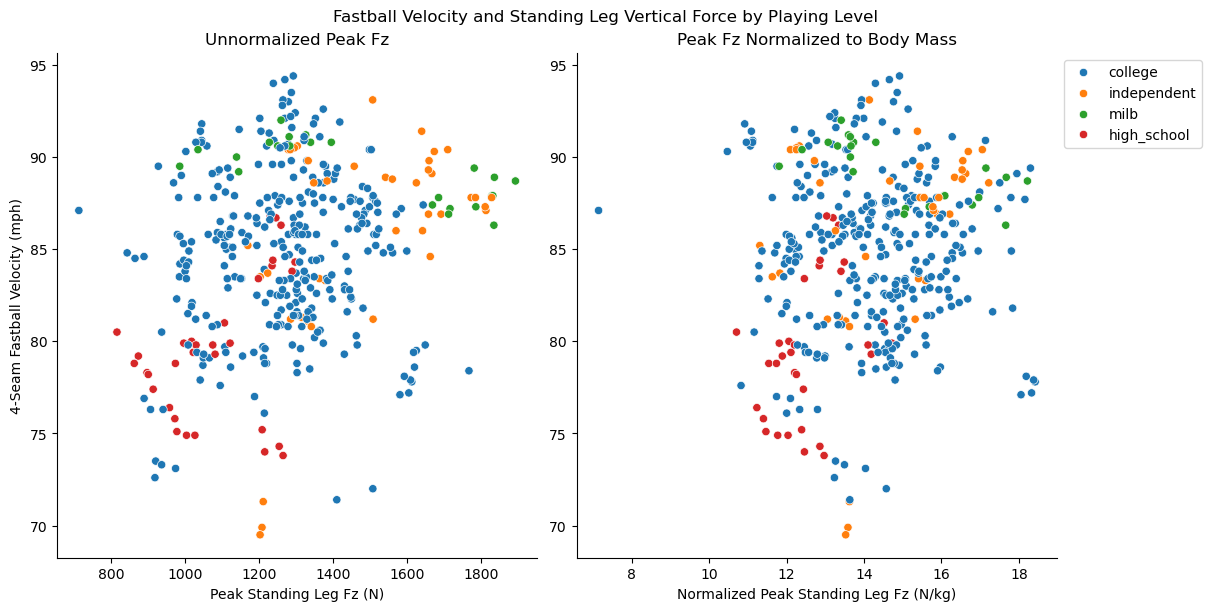

In [15]:
# Plot unnormalized and normalized 4-seam fastball velocity vs. force plate (Fz) values and distinguished by pitcher playing level

# Prepare data using pitch IDs from pitch_array to get corresponding playing level from metadata.csv
playing_level_array = pitcher_metadata_df['playing_level'][pitcher_metadata_df['session_pitch'].isin(pitch_array)].to_numpy()

# Set axes for plots
fig, (unnormalized_plot_axes, normalized_plot_axes) = plt.subplots(1, 2, figsize=(12,6), layout='constrained')
fig.suptitle('Fastball Velocity and Standing Leg Vertical Force by Playing Level')

# Plot data
# Velocity vs. Unnormalized Peak Fz
sns.scatterplot(x=peak_fz_array, y=pitch_velos_array, hue=playing_level_array, legend=False, ax=unnormalized_plot_axes)
unnormalized_plot_axes.set_xlabel('Peak Standing Leg Fz (N)')
unnormalized_plot_axes.set_ylabel('4-Seam Fastball Velocity (mph)')
unnormalized_plot_axes.set_title('Unnormalized Peak Fz')
unnormalized_plot_axes.spines[['top', 'right']].set_visible(False)

# Velocity vs. Normalized Peak Fz
velo_normfz_plot = sns.scatterplot(x=normalized_fz_array, y=pitch_velos_array, hue=playing_level_array, legend='full', ax=normalized_plot_axes) # creating separate object to move the legend
sns.move_legend(velo_normfz_plot, loc='upper left', bbox_to_anchor=(1, 1))
normalized_plot_axes.set_xlabel('Normalized Peak Standing Leg Fz (N/kg)')
normalized_plot_axes.set_title('Peak Fz Normalized to Body Mass')
normalized_plot_axes.spines[['top', 'right']].set_visible(False)

In [16]:
# Mean Peak Standing Leg Fz and Fastball Velocity Data by Playing Level
fz_velocity_df = pd.DataFrame({'Unnormalized Fz': peak_fz_array,
                               'Normalized Fz': normalized_fz_array,
                               'Velocity': pitch_velos_array,
                               'Playing Level': playing_level_array})

fz_velocity_df.groupby('Playing Level')[['Unnormalized Fz', 'Normalized Fz', 'Velocity']].mean()

,Unnormalized Fz,Normalized Fz,Velocity
Playing Level,,,
college,1261.830059,14.250845,84.841694
high_school,1079.868631,12.552783,79.515625
independent,1485.119280,14.507928,85.897561
milb,1488.498048,14.899869,89.247826


Text(18, 84, 'R = 0.1061, R^2 = 0.0113')

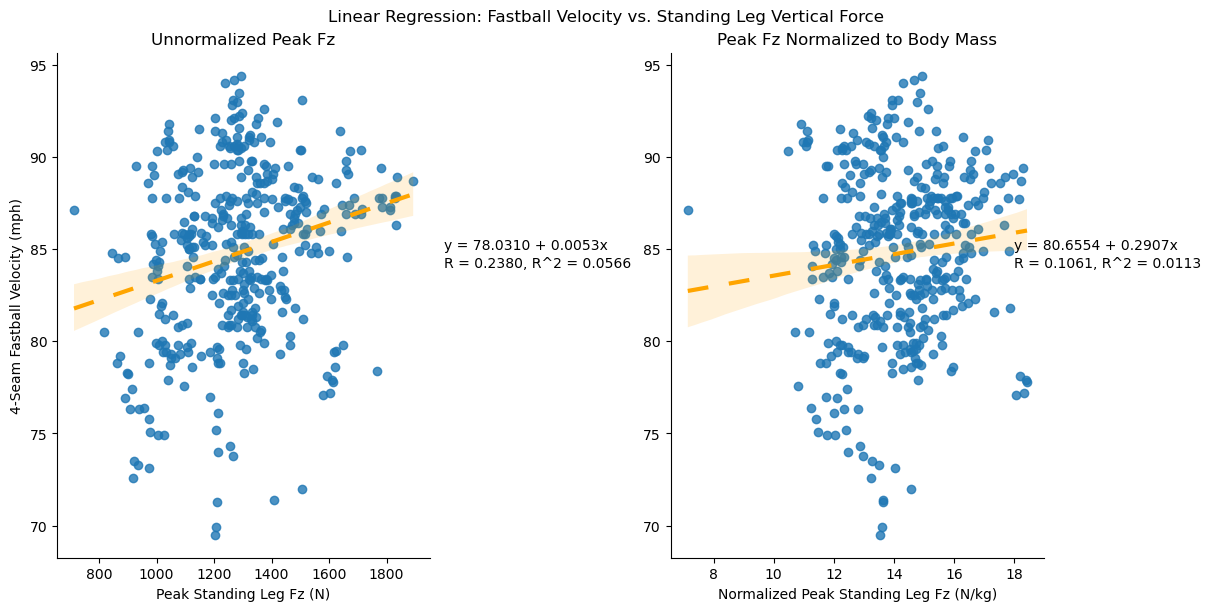

In [17]:
# Plot linear regression plots of 4-seam fastball velocity vs. vertical force data with 95% confidence interval of regression line

# Set axes for plots
fig, (unnormalized_regression_axes, normalized_regression_axes) = plt.subplots(1, 2, figsize=(12,6), layout='constrained')
fig.suptitle('Linear Regression: Fastball Velocity vs. Standing Leg Vertical Force')

# Unnormalized
# Regression plot
sns.regplot(x=peak_fz_array, y=pitch_velos_array, scatter=True, fit_reg=True, ci=95, seed=42, ax=unnormalized_regression_axes,
            line_kws={'color': 'orange',
                      'linestyle': (0, (5,5)),
                      'linewidth': 3})
unnormalized_regression_axes.set_xlabel('Peak Standing Leg Fz (N)')
unnormalized_regression_axes.set_ylabel('4-Seam Fastball Velocity (mph)')
unnormalized_regression_axes.set_title('Unnormalized Peak Fz')
unnormalized_regression_axes.spines[['top', 'right']].set_visible(False)

# Calculate and label linear regrssion equation and metrics
unnormalized_linregress_results = scipy.stats.linregress(x=peak_fz_array, y=pitch_velos_array)
unnormalized_regression_axes.text(2000, 85, f'y = {unnormalized_linregress_results.intercept:.4f} + {unnormalized_linregress_results.slope:.4f}x', fontsize='medium') # label for line of best fit equation
unnormalized_regression_axes.text(2000, 84, f'R = {unnormalized_linregress_results.rvalue:.4f}, R^2 = {unnormalized_linregress_results.rvalue**2:.4f}', fontsize='medium') # label for R and R-squared coefficients

# Normalized
# Regression plot
sns.regplot(x=normalized_fz_array, y=pitch_velos_array, scatter=True, fit_reg=True, ci=95, seed=42, ax=normalized_regression_axes,
            line_kws={'color': 'orange',
                      'linestyle': (0, (5,5)),
                      'linewidth': 3})
normalized_regression_axes.set_xlabel('Normalized Peak Standing Leg Fz (N/kg)')
normalized_regression_axes.set_title('Peak Fz Normalized to Body Mass')
normalized_regression_axes.spines[['top', 'right']].set_visible(False)

# Calculate and label linear regrssion equation and metrics
normalized_linregress_results = scipy.stats.linregress(x=normalized_fz_array, y=pitch_velos_array)
normalized_regression_axes.text(18, 85, f'y = {normalized_linregress_results.intercept:.4f} + {normalized_linregress_results.slope:.4f}x', fontsize='medium') # label for line of best fit equation
normalized_regression_axes.text(18, 84, f'R = {normalized_linregress_results.rvalue:.4f}, R^2 = {normalized_linregress_results.rvalue**2:.4f}', fontsize='medium') # label for R and R-squared coefficients

Stronger linear relationships than the observed correlation coefficient (Pearson *r*) values of 0.2380 (velocity vs. unnormalized vertical force) and 0.1060 (velocity vs. normalized vertical force) were hypothesized. Since real-world motion is seldom along one axis, the relationship is re-evaluated using the resultant 3D force applied during the pitch.

## Examining the Relationship Between Velocity and 3D Resultant Force

In [18]:
# Calculate 3D resultant force magnitude using x, y, z force components from force plate data

# Convert standing leg force dataframe columns to numpy arrays for more efficient computing
standing_fx_array = force_plate_df['rear_force_x'].to_numpy()
standing_fy_array = force_plate_df['rear_force_y'].to_numpy()
standing_fz_array = force_plate_df['rear_force_z'].to_numpy()

# Compute 3D resultant force magnitude
resultant_force_array = np.sqrt(np.square(standing_fx_array) + np.square(standing_fy_array) + np.square(standing_fz_array))

In [19]:
# Return an array for the pitch ID and an array for the peak resultant force magnitude for each recorded pitch
# Suppress 1st output of get_event_value function because pitch_array already exists
_, peak_resultant_array = get_event_value(pd.concat([force_plate_df['time'], pd.Series(resultant_force_array, name='standing_resultant_force')], axis=1), 'standing_resultant_force')

In [20]:
# Calculate peak resultant force normalized to pitcher mass
normalized_resultant_array = peak_resultant_array / pitcher_mass_array

### Plots

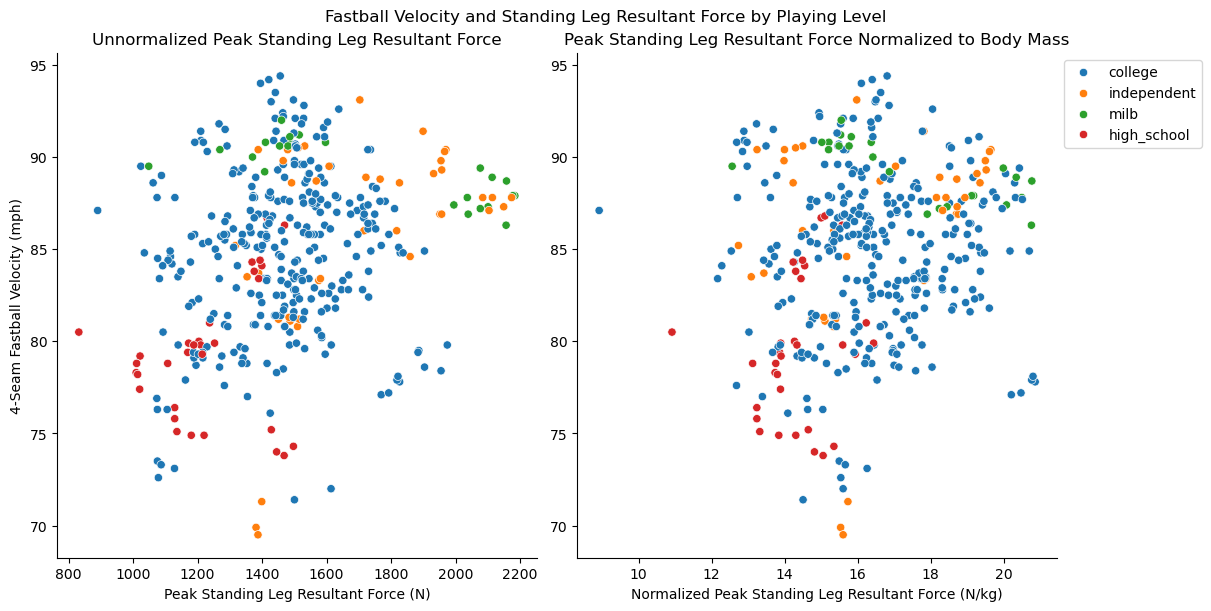

In [21]:
# Plot unnormalized and normalized 4-seam fastball velocity vs. resultant force magnitudes and distinguished by pitcher playing level

# Variables in play for upcoming plots:
# - playing_level_array -> already created in previous set of plots
# - pitch_velos_array -> already created in previous set of plots
# - peak_resultant_array
# - normalized_resultant_array

# Set axes for plots
fig, (unnormalized_resultant_axes, normalized_resultant_axes) = plt.subplots(1, 2, figsize=(12,6), layout='constrained')
fig.suptitle('Fastball Velocity and Standing Leg Resultant Force by Playing Level')

# Plot data
# Velocity vs. Unnormalized Peak 3D Resultant Force
sns.scatterplot(x=peak_resultant_array, y=pitch_velos_array, hue=playing_level_array, legend=False, ax=unnormalized_resultant_axes)
unnormalized_resultant_axes.set_xlabel('Peak Standing Leg Resultant Force (N)')
unnormalized_resultant_axes.set_ylabel('4-Seam Fastball Velocity (mph)')
unnormalized_resultant_axes.set_title('Unnormalized Peak Standing Leg Resultant Force')
unnormalized_resultant_axes.spines[['top', 'right']].set_visible(False)

# Velocity vs. Normalized Peak 3D Resultant Force
velo_norm3dforce_plot = sns.scatterplot(x=normalized_resultant_array, y=pitch_velos_array, hue=playing_level_array, legend='full', ax=normalized_resultant_axes) # creating separate object to move the legend
sns.move_legend(velo_norm3dforce_plot, loc='upper left', bbox_to_anchor=(1, 1))
normalized_resultant_axes.set_xlabel('Normalized Peak Standing Leg Resultant Force (N/kg)')
normalized_resultant_axes.set_title('Peak Standing Leg Resultant Force Normalized to Body Mass')
normalized_resultant_axes.spines[['top', 'right']].set_visible(False)

In [22]:
# Mean Peak Standing Leg Resultant Force and Fastball Velocity Data by Playing Level
resultant_velocity_df = pd.DataFrame({'Unnormalized Resultant Force': peak_resultant_array,
                               'Normalized Resultant Force': normalized_resultant_array,
                               'Velocity': pitch_velos_array,
                               'Playing Level': playing_level_array})

resultant_velocity_df.groupby('Playing Level')[['Unnormalized Resultant Force', 'Normalized Resultant Force', 'Velocity']].mean()

,Unnormalized Resultant Force,Normalized Resultant Force,Velocity
Playing Level,,,
college,1456.881908,16.462660,84.841694
high_school,1235.549087,14.352173,79.515625
independent,1695.019052,16.552695,85.897561
milb,1743.301368,17.443112,89.247826


Text(20, 82, 'R = 0.1517, R^2 = 0.0230')

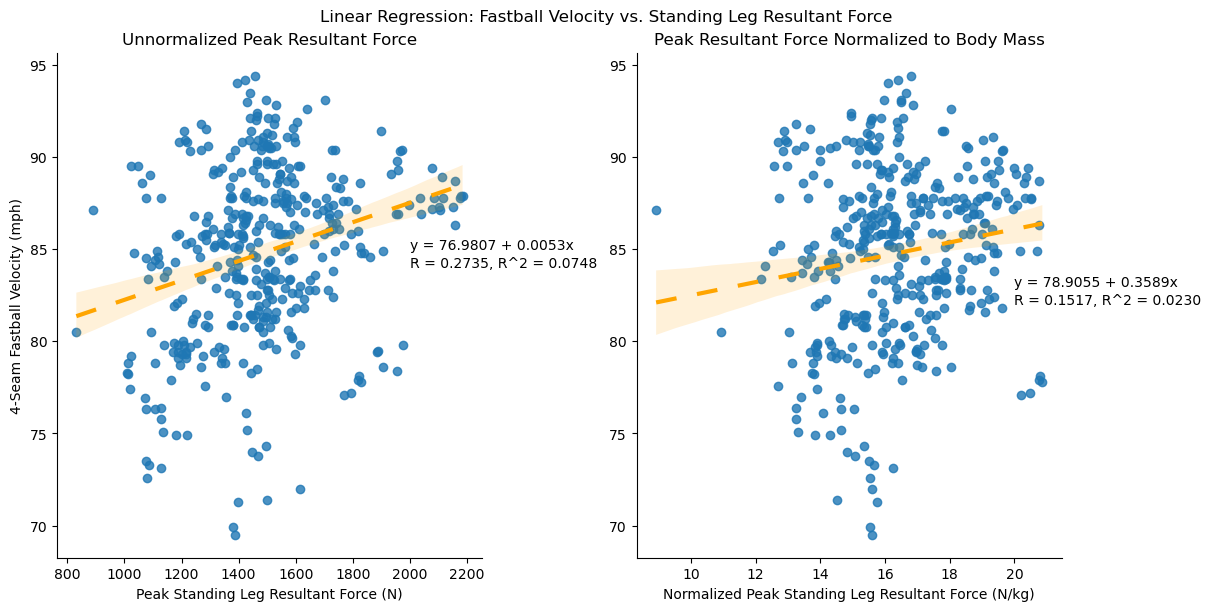

In [23]:
# Plot linear regression plots of 4-seam fastball velocity vs. resultant force with 95% confidence interval of regression line

# Set axes for plots
fig, (unnormalized_resultant_regression_axes, normalized_resultant_regression_axes) = plt.subplots(1, 2, figsize=(12,6), layout='constrained')
fig.suptitle('Linear Regression: Fastball Velocity vs. Standing Leg Resultant Force')

# Unnormalized
# Regression plot
sns.regplot(x=peak_resultant_array, y=pitch_velos_array, scatter=True, fit_reg=True, ci=95, seed=42, ax=unnormalized_resultant_regression_axes,
            line_kws={'color': 'orange',
                      'linestyle': (0, (5,5)),
                      'linewidth': 3})
unnormalized_resultant_regression_axes.set_xlabel('Peak Standing Leg Resultant Force (N)')
unnormalized_resultant_regression_axes.set_ylabel('4-Seam Fastball Velocity (mph)')
unnormalized_resultant_regression_axes.set_title('Unnormalized Peak Resultant Force')
unnormalized_resultant_regression_axes.spines[['top', 'right']].set_visible(False)

# Calculate and label linear regrssion equation and metrics
unnorm_resultant_linregress_results = scipy.stats.linregress(x=peak_resultant_array, y=pitch_velos_array)
unnormalized_resultant_regression_axes.text(2000, 85, f'y = {unnorm_resultant_linregress_results.intercept:.4f} + {unnorm_resultant_linregress_results.slope:.4f}x', fontsize='medium') # label for line of best fit equation
unnormalized_resultant_regression_axes.text(2000, 84, f'R = {unnorm_resultant_linregress_results.rvalue:.4f}, R^2 = {unnorm_resultant_linregress_results.rvalue**2:.4f}', fontsize='medium') # label for R and R-squared coefficients

# Normalized
# Regression plot
sns.regplot(x=normalized_resultant_array, y=pitch_velos_array, scatter=True, fit_reg=True, ci=95, seed=42, ax=normalized_resultant_regression_axes,
            line_kws={'color': 'orange',
                      'linestyle': (0, (5,5)),
                      'linewidth': 3})
normalized_resultant_regression_axes.set_xlabel('Normalized Peak Standing Leg Resultant Force (N/kg)')
normalized_resultant_regression_axes.set_title('Peak Resultant Force Normalized to Body Mass')
normalized_resultant_regression_axes.spines[['top', 'right']].set_visible(False)

# Calculate and label linear regrssion equation and metrics
norm_resultant_linregress_results = scipy.stats.linregress(x=normalized_resultant_array, y=pitch_velos_array)
normalized_resultant_regression_axes.text(20, 83, f'y = {norm_resultant_linregress_results.intercept:.4f} + {norm_resultant_linregress_results.slope:.4f}x', fontsize='medium') # label for line of best fit equation
normalized_resultant_regression_axes.text(20, 82, f'R = {norm_resultant_linregress_results.rvalue:.4f}, R^2 = {norm_resultant_linregress_results.rvalue**2:.4f}', fontsize='medium') # label for R and R-squared coefficients

## Conclusion

Considering the resultant ground reaction force (GRF) during pitching increased the strength of the linear relationship between the fastball velocity and standing leg force compared to when only considering Fz.

**Unnormalized *r* value**: 0.2380 -> 0.2735  
**Normalized *r* value**: 0.1061 -> 0.1517

Future analyses calculating feature importance from fastball velocity regression models with more features and tracking energy flow during a pitch would give a clearer picture on the most influential factors on fastball velocity. 